In [1]:
import numpy as np
import polars as pl

from embedding import Word2VecParser, Word2Vec

import matplotlib.pyplot as plt

RAW_DATA = "data/corpora.txt"

In [3]:
texts = pl.scan_ndjson('hf://datasets/sentence-transformers/reddit-title-body/**/*.jsonl.gz').head(50_000).collect()
with open(RAW_DATA, mode='w+') as file:
    file.writelines(texts['body'])
(
    texts.select(
        pl.col('body').str.len_chars().alias("len_chars"),
        pl.col('body').str.split(by=' ').list.len().alias("len_words")
    ).describe()
)

statistic,len_chars,len_words
str,f64,f64
"""count""",50000.0,50000.0
"""null_count""",0.0,0.0
"""mean""",623.78926,114.37102
"""std""",615.486933,113.493792
"""min""",52.0,1.0
"""25%""",232.0,43.0
"""50%""",413.0,76.0
"""75%""",772.0,141.0
"""max""",4095.0,1296.0


## Word2Vec Implementation

Here you can find a demonstration of training a word2vec skip-gram version and some analysis of the results. Wikipedia articles are used to train embeddings, evaluation is performed using spearman's correlation on the WordSim353 dataset.

In [2]:
# helper functions

def viz_losses(train_losses, val_losses):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 4))
    plt.plot(epochs, train_losses, label="train loss", lw=2, marker='o')
    plt.plot(epochs, val_losses, label="validation loss", lw=2, marker='o')
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.grid(True)
    plt.show()

def viz_norms(norms_dict: dict, title):
    plt.figure(figsize=(12, 4))
    for param_name in norms_dict.keys():
        plt.plot(range(1, len(norms_dict[param_name]) + 1), norms_dict[param_name], label=param_name)
    plt.xlabel("step")
    plt.ylabel("l2-norm")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def cosine_similarity(first_embedding, second_embedding):
    return first_embedding @ second_embedding / (np.linalg.norm(first_embedding) * np.linalg.norm(second_embedding))

## Training

Let's try to train word2vec with the default optimizer settings (Adam is used):

* lr=0.001
* b1 = 0.9 (the strength of exponential smoothing for the first gradient momentum)
* b2 = 0.999 (the strength of exponential smoothing for the second gradient momentum)

In [3]:
import pickle

# with open('data/vocab_default.pkl', 'wb') as file:
#     pickle.dump(vocab_default, file)

# with open('data/vocab_default.pkl', 'rb') as file:
#     vocab_default = pickle.load(file)

In [4]:
word2vec_data_filename = 'data/word_contexts_default.csv'
parser = Word2VecParser(RAW_DATA)
# window_size=5, k=5, min_count=10
vocab_default = parser.parse_positive_negative_samples(word2vec_data_filename)
print(f'Vocab size: {len(vocab_default)}')

5564543it [04:30, 20594.25it/s]

Vocab size: 17576


In [5]:
word2vec_data = pl.scan_csv(word2vec_data_filename, has_header=False, with_column_names=lambda _: ['center', 'context', 'label'])

epoch:   0%|          | 0/5 [00:00<?, ?it/s]

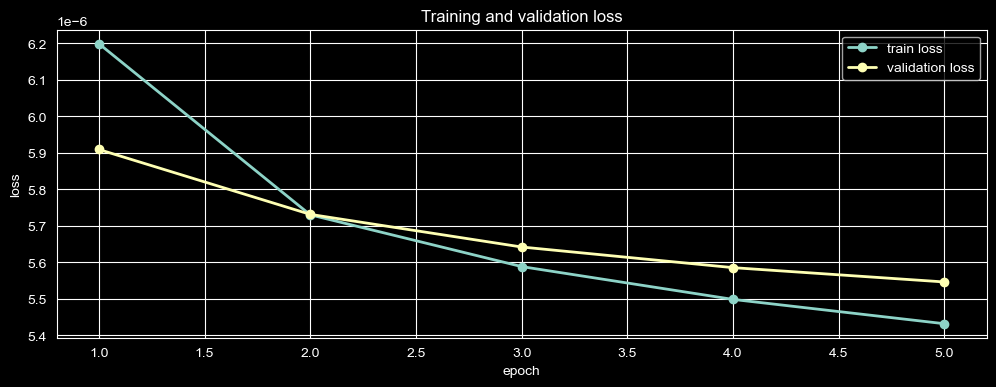

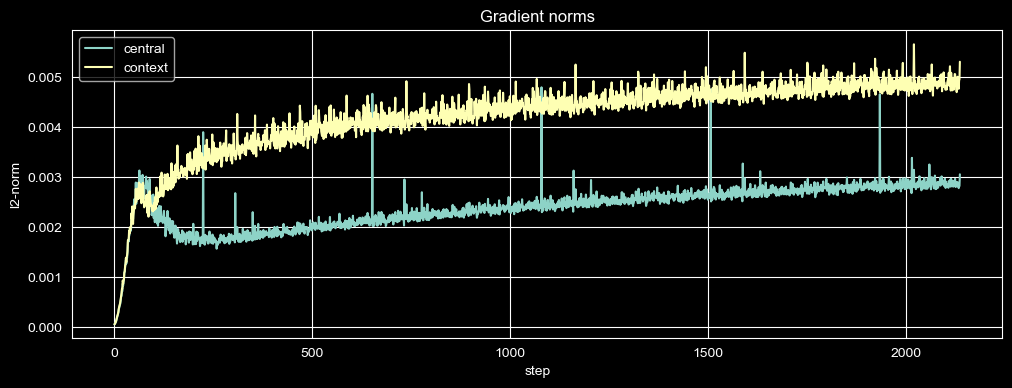

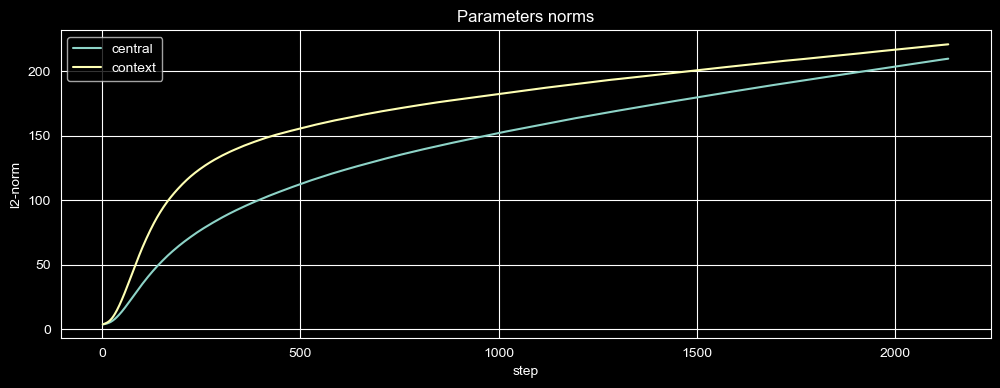

In [7]:
model = Word2Vec.from_scratch(dataset=word2vec_data, vocab=vocab_default, embedding_size=100, batch_size=100_000)
model.train(epoches=5)

viz_losses(model.train_losses_, model.val_losses_)
viz_norms(model.gradient_norms_, "Gradient norms")
viz_norms(model.parameter_norms_, "Parameters norms")

In [8]:
model.save_pretrained('data/word2vec/baseline')

In [9]:
word2vec_data_filename = 'data/word_contexts_smaller_window.csv'
parser = Word2VecParser(RAW_DATA)
vocab_smaller_window = parser.parse_positive_negative_samples(word2vec_data_filename, window_size=3)
print(f'Vocab size: {len(vocab_smaller_window)}')

5564543it [04:30, 20555.49it/s]

Vocab size: 17576


epoch:   0%|          | 0/5 [00:00<?, ?it/s]

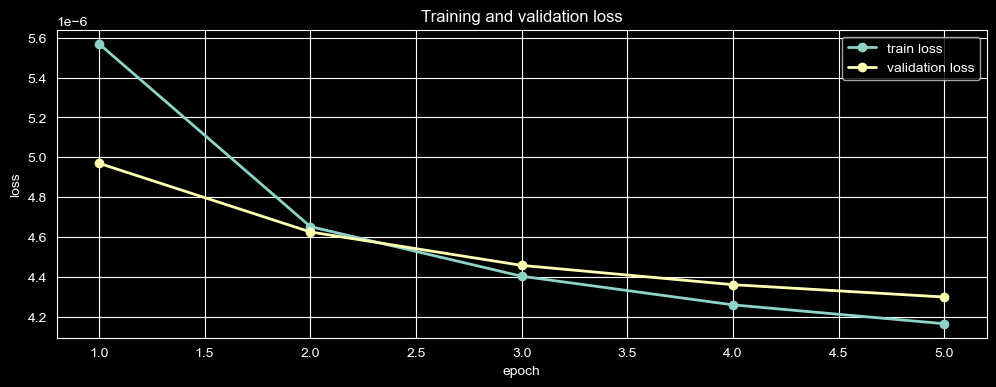

In [10]:
data = pl.scan_csv(word2vec_data_filename, has_header=False, with_column_names=lambda _: ['center', 'context', 'label'])
model = Word2Vec.from_scratch(dataset=data, vocab=vocab_smaller_window, embedding_size=100, batch_size=100_000)
model.train(epoches=5)

viz_losses(model.train_losses_, model.val_losses_)

In [11]:
model.save_pretrained('data/word2vec/smaller_window')

In [12]:
word2vec_data_filename = 'data/word_contexts_bigger_window.csv'
parser = Word2VecParser(RAW_DATA)
vocab_bigger_window = parser.parse_positive_negative_samples(word2vec_data_filename, window_size=7)
print(f'Vocab size: {len(vocab_bigger_window)}')

5564543it [04:41, 19772.41it/s]

Vocab size: 17576


epoch:   0%|          | 0/5 [00:00<?, ?it/s]

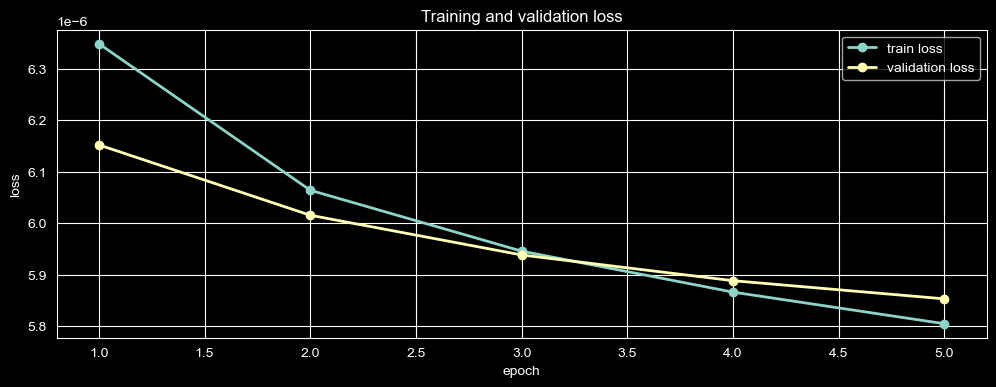

In [13]:
data = pl.scan_csv(word2vec_data_filename, has_header=False, with_column_names=lambda _: ['center', 'context', 'label'])
model = Word2Vec.from_scratch(dataset=data, vocab=vocab_bigger_window, embedding_size=100, batch_size=100_000)
model.train(epoches=5)

viz_losses(model.train_losses_, model.val_losses_)

In [15]:
model.save_pretrained('data/word2vec/bigger_window')